In [219]:
from mGST.utility_functions_comparisons import get_full_mgst_parameters_from_configuration, factorize_psd_truncated, create_4q_gst_config
from iqm.benchmarks.compressive_gst.compressive_gst import GSTConfiguration
 
from mGST.low_level_jit import cost_function_numba, cost_function_jax_mps

import jax.numpy as jnp
import jax

import numpy as np

import matplotlib.pyplot as plt

backend = "iqmfakeapollo"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Check new functions using factorizations for $\rho$ and $E$ (POVM)

# 2GST

In [2]:
# let's start with a 2 qubit one to check with numba.
Q2_GST = GSTConfiguration(
    qubit_layouts=[[0, 1]],
    gate_set="2QXYCZ",
    num_circuits=800,
    shots=1000,
    rank=4,
)

K, X, E, rho, y, J, l, d, pdim, r, n_povm, bsize, meas_samples, n, nt, rK = get_full_mgst_parameters_from_configuration(
    Q2_GST, backend
)

2025-02-17 16:15:01,969 - iqm.benchmarks.logging_config - INFO - Now generating 800 random GST circuits...
2025-02-17 16:15:02,553 - iqm.benchmarks.logging_config - INFO - Will transpile all 800 circuits according to fixed physical layout
2025-02-17 16:15:02,553 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2025-02-17 16:15:04,302 - iqm.benchmarks.logging_config - INFO - Submitting batch with 800 circuits corresponding to qubits [0, 1]
2025-02-17 16:15:04,322 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2025-02-17 16:15:04,373 - iqm.benchmarks.logging_config - INFO - Retrieving all counts
INFO:2025-02-17 16:15:10,035:jax._src.xla_bridge:927: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2025-02-17 16:15:10,035 - jax._src.xla_bridge - INFO - Unable to initialize backend 'rocm': module 'ja

In [3]:
K_np = np.array(K)
E_np = np.array(E)
rho_np = np.array(rho)
y_np = np.array(y)

## Cost function

In [167]:
cost_value_numba_2q = cost_function_numba(K_np, E_np, rho_np, J, y_np)
cost_value_numba_2q

0.0015886332887399726

In [169]:
E_np.shape

(4, 16)

In [5]:
# creating the parameters needed for the jax version
num_povm = E.shape[0]
dim = int(jnp.sqrt(E.shape[1]))

povm_tensor = jnp.reshape(E, shape=(num_povm, dim, dim))
state = jnp.reshape(rho, shape=(dim, dim))

indices_list = [indices[indices != -1] for indices in J]

kraus_tensor = K
prob_matrix = y

state_psd = factorize_psd_truncated(psd=state, max_rank=1)
jnp.allclose(state_psd @ state_psd.T, state)

Array(True, dtype=bool)

In [6]:
cost_value_jax_2q = cost_function_jax_mps(kraus_tensor, povm_tensor, state_psd, indices_list, prob_matrix)
jnp.allclose(cost_value_jax_2q, cost_value_numba_2q)

Array(True, dtype=bool)

In [7]:
state_cholesky = jnp.linalg.cholesky(state)
jnp.allclose(state_cholesky @ state_cholesky.T.conj(), state)

Array(False, dtype=bool)

In [106]:
povm_psd  = factorize_psd_truncated(psd=povm_tensor, max_rank=1)
povm_psd.shape

(4, 4, 1)

In [107]:
jnp.allclose(jnp.einsum("ijk, ilk -> ijl", povm_psd, povm_psd.conj()), povm_tensor)

Array(True, dtype=bool)

In [10]:
povm_psd.shape

(4, 4, 1)

In [11]:
jnp.allclose(povm_psd @ povm_psd.conj().transpose(0, 2, 1), povm_tensor)

Array(True, dtype=bool)

In [12]:
cost_value_jax_2q_factorized_full = cost_function_jax_mps(kraus_tensor, povm_tensor, state_psd, indices_list, prob_matrix)
jnp.allclose(cost_value_jax_2q_factorized_full, cost_value_numba_2q)

Array(True, dtype=bool)

In [145]:
%time cost_function_jax_mps(kraus_tensor, povm_tensor, state_psd, indices_list, prob_matrix)

CPU times: user 858 ms, sys: 34.1 ms, total: 892 ms
Wall time: 765 ms


Array(0.00166135, dtype=float64)

In [148]:
%timeit cost_function_jax_mps(kraus_tensor, povm_tensor, state_psd, indices_list, prob_matrix)
# using the hadamard product:
# 726 ms ± 12 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

708 ms ± 3.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [139]:
jnp.einsum("ijk, jl, ilk -> i", povm_psd, state, povm_psd.conj())

Array([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j], dtype=complex128)

In [140]:
jnp.einsum_path("ijk, jl, ilk -> i", povm_psd, state, povm_psd.conj())

([(0, 1), (0, 1)],
   Complete contraction:  ijk,jl,ilk->i
          Naive scaling:  4
      Optimized scaling:  4
       Naive FLOP count:  1.920e+2
   Optimized FLOP count:  1.600e+2
    Theoretical speedup:  1.200e+0
   Largest intermediate:  1.600e+1 elements
 --------------------------------------------------------------------------------
 scaling        BLAS                current                             remaining
 --------------------------------------------------------------------------------
    4           TDOT            jl,ijk->lik                            ilk,lik->i
    3              0             lik,ilk->i                                  i->i)

## Gradients

### State

In [92]:
from mGST.low_level_jit import gradient_state_mps, ddB_derivs, ddA_derivs, gradient_povm_mps, gradient_k_mps, gradient_all_3_mps

In [51]:
state_psd = factorize_psd_truncated(psd=state, max_rank=1)
povm_psd = factorize_psd_truncated(psd=povm_tensor, max_rank=1)
gradient_state_jax = gradient_state_mps(kraus=kraus_tensor, povm_psd=povm_psd, state_psd=state_psd, indices_list=indices_list, prob_matrix=prob_matrix)

Using JAX power


In [52]:
gradient_state_jax

Array([[0.02454385+0.j        ],
       [0.00041874+0.00361625j],
       [0.00014851-0.00301129j],
       [0.00018026-0.00125755j]], dtype=complex128)

In [43]:
# gradient_state_jax[:,0]
# If we don't restrict the rank of the state, we get a gradient of dim x dim instead of dim x rank.
# But only the first column has non-zero values.

Array([0.02454385+0.j        , 0.00041874+0.00361625j,
       0.00014851-0.00301129j, 0.00018026-0.00125755j], dtype=complex128)

In [100]:
A = np.array([np.linalg.cholesky(E_np[k].reshape(pdim, pdim) + 1e-14 * np.eye(pdim)).T.conj() for k in range(n_povm)])
A_np = np.array(factorize_psd_truncated(psd=povm_tensor))
# B = np.array(state_psd)
B = np.linalg.cholesky(state + 1e-14 * np.eye(pdim)).T.conj()
X_np = np.array(X)
[type(element) for element in(X_np, A_np, B, J, y_np, r, pdim)]

[numpy.ndarray,
 numpy.ndarray,
 numpy.ndarray,
 numpy.ndarray,
 numpy.ndarray,
 int,
 int]

In [137]:
E_test = np.array([(A[i].T.conj() @ A[i]) for i in range(n_povm)])
jnp.allclose(E_test, povm_tensor)

Array(True, dtype=bool)

In [138]:
jnp.allclose(A @ A.conj().transpose(0, 2, 1), povm_tensor)

Array(True, dtype=bool)

In [139]:
jnp.allclose(povm_psd @ povm_psd.conj().transpose(0, 2, 1), povm_tensor)

Array(True, dtype=bool)

In [136]:
povm_tensor.shape, povm_psd.shape, A.shape

((4, 4, 4), (4, 4, 1), (4, 4, 4))

In [130]:
for povm in povm_tensor:
    print("-------")
    print(povm)

-------
[[1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]]
-------
[[0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]]
-------
[[0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]]
-------
[[0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j]]


In [142]:
for tensor in A:
    print("-------")
    print(tensor[tensor.nonzero()])

-------
[1.e+00-0.j 1.e-07-0.j 1.e-07-0.j 1.e-07-0.j]
-------
[1.e-07-0.j 1.e+00-0.j 1.e-07-0.j 1.e-07-0.j]
-------
[1.e-07-0.j 1.e-07-0.j 1.e+00-0.j 1.e-07-0.j]
-------
[1.e-07-0.j 1.e-07-0.j 1.e-07-0.j 1.e+00-0.j]


In [141]:
for tensor in A_np:
    print("-------")
    print(tensor.nonzero())

-------
(array([0]), array([0]))
-------
(array([1]), array([0]))
-------
(array([2]), array([0]))
-------
(array([3]), array([0]))


In [ ]:
jnp.allclose(A[0], A_np[0])

Array(False, dtype=bool)

In [145]:
A[1], A_np[1]

(array([[1.e-07-0.j, 0.e+00-0.j, 0.e+00-0.j, 0.e+00-0.j],
        [0.e+00-0.j, 1.e+00-0.j, 0.e+00-0.j, 0.e+00-0.j],
        [0.e+00-0.j, 0.e+00-0.j, 1.e-07-0.j, 0.e+00-0.j],
        [0.e+00-0.j, 0.e+00-0.j, 0.e+00-0.j, 1.e-07-0.j]]),
 array([[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]]))

In [103]:
gradient_state_numba, *_  = ddB_derivs(X=X_np, A=A, B=B, J=J, y=y_np, r=r, pdim=pdim)

In [104]:
jnp.allclose(gradient_state_numba[:,0], gradient_state_jax[:,0]/2)

Array(True, dtype=bool)

### POVM

In [67]:
gradient_povm_numba, *_  = ddA_derivs(X=X_np, A=A, B=B, J=J, y=y_np, r=r, pdim=pdim, n_povm=n_povm)

OMP: Info #271: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [74]:
gradient_povm_jax = gradient_povm_mps(kraus=kraus_tensor, povm_psd=povm_psd, state_psd=state_psd, indices_list=indices_list, prob_matrix=prob_matrix)

Using JAX power


In [80]:
gradient_povm_numba.shape, gradient_povm_jax.shape

((4, 4, 4), (4, 4, 1))

In [76]:
jnp.allclose(gradient_povm_numba[:,:,0], gradient_povm_jax[:,:,0]/2)

Array(False, dtype=bool)

In [87]:
gradient_povm_jax[:,:,0].real/2

Array([[ 2.35184612e-03, -2.47648215e-05,  3.28036878e-04,
         3.12403813e-04],
       [ 2.27922396e-04,  3.74820254e-03,  6.86528770e-05,
         3.84655632e-04],
       [-3.40039926e-04,  9.81106725e-05,  2.95738287e-03,
         1.02142830e-04],
       [-3.53295451e-05, -3.32939389e-04, -3.95535483e-05,
         3.21449121e-03]], dtype=float64)

In [85]:
gradient_povm_numba[:,:,0].real

array([[ 2.34733050e-03, -2.47983507e-12,  3.32646215e-11,
         3.12828769e-11],
       [-8.72571394e-11,  2.25787160e-04,  1.14688593e-11,
        -1.16628500e-11],
       [-8.44942562e-11, -8.19694081e-12, -3.40039261e-04,
        -1.62693342e-11],
       [-6.27608632e-11, -1.20608254e-11, -1.00346385e-11,
        -3.24462536e-05]])

In [84]:
jnp.abs(gradient_povm_numba[:,:,0] - gradient_povm_jax[:,:,0]/2)

Array([[4.51562835e-06, 3.62662900e-04, 4.31391842e-04, 3.83961000e-04],
       [6.11498541e-04, 3.56779971e-03, 4.15984182e-04, 4.18349291e-04],
       [4.18072701e-04, 1.91035328e-04, 3.30638068e-03, 1.04431966e-04],
       [1.61576899e-04, 3.37133048e-04, 5.82220244e-05, 3.25077384e-03]],      dtype=float64)

In [88]:
%timeit _ = gradient_state_mps(kraus=kraus_tensor, povm_psd=povm_psd, state_psd=state_psd, indices_list=indices_list, prob_matrix=prob_matrix)

Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
3.78 s ± 37.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [90]:
%timeit _ = gradient_k_mps(kraus=kraus_tensor, povm_psd=povm_psd, state_psd=state_psd, indices_list=indices_list, prob_matrix=prob_matrix)

Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
6.34 s ± 48.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [91]:
%timeit _ = gradient_povm_mps(kraus=kraus_tensor, povm_psd=povm_psd, state_psd=state_psd, indices_list=indices_list, prob_matrix=prob_matrix)

Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
2.91 s ± 29.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [93]:
%timeit _ = gradient_all3_mps(kraus=kraus_tensor, povm_psd=povm_psd, state_psd=state_psd, indices_list=indices_list, prob_matrix=prob_matrix)

Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
6.69 s ± 43.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [94]:
grad_kraus_, grad_povm_, grad_state_ = gradient_all_3_mps(kraus=kraus_tensor, povm_psd=povm_psd, state_psd=state_psd, indices_list=indices_list, prob_matrix=prob_matrix)

Using JAX power


In [96]:
grad_kraus_.shape, grad_povm_.shape, grad_state_.shape

((5, 4, 4, 4), (4, 4, 1), (4, 1))

In [98]:
jnp.allclose(grad_povm_, gradient_povm_jax), jnp.allclose(grad_state_, gradient_state_jax)

(Array(True, dtype=bool), Array(True, dtype=bool))

### All gradients with value

In [216]:
from mGST.low_level_jit import gradient_all_3_and_value, gradient_all_3_and_value_jit

In [205]:
value, gradient = gradient_all_3_and_value(kraus=kraus_tensor, povm_psd=povm_psd, state_psd=state_psd, indices_list=indices_list, prob_matrix=prob_matrix)

In [208]:
jnp.allclose(gradient[0], grad_kraus_), jnp.allclose(gradient[1], grad_povm_), jnp.allclose(gradient[2], grad_state_)

(Array(True, dtype=bool), Array(True, dtype=bool), Array(True, dtype=bool))

In [209]:
%timeit gradient_all_3_and_value(kraus=kraus_tensor, povm_psd=povm_psd, state_psd=state_psd, indices_list=indices_list, prob_matrix=prob_matrix)

6.83 s ± 224 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


# 3GST

In [210]:
Q3_GST = GSTConfiguration(
    qubit_layouts=[[0,1,3]],
    gate_set="3QXYCZ",
    num_circuits=1000,
    shots=1000,
    rank=4,
)

K, X, E, rho, y, J, l, d, pdim, r, n_povm, bsize, meas_samples, n, nt, rK = get_full_mgst_parameters_from_configuration(
    Q3_GST, backend
)

2025-02-17 19:43:03,311 - iqm.benchmarks.logging_config - INFO - Now generating 1000 random GST circuits...
2025-02-17 19:43:03,538 - iqm.benchmarks.logging_config - INFO - Will transpile all 1000 circuits according to fixed physical layout
2025-02-17 19:43:03,538 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2025-02-17 19:43:06,347 - iqm.benchmarks.logging_config - INFO - Submitting batch with 1000 circuits corresponding to qubits [0, 1, 3]
2025-02-17 19:43:06,352 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2025-02-17 19:43:06,397 - iqm.benchmarks.logging_config - INFO - Retrieving all counts


In [213]:
K_np = np.array(K)
E_np = np.array(E)
rho_np = np.array(rho)
y_np = np.array(y)

In [211]:
# creating the parameters needed for the jax version
num_povm = E.shape[0]
dim = int(jnp.sqrt(E.shape[1]))

povm_tensor = jnp.reshape(E, shape=(num_povm, dim, dim))
state = jnp.reshape(rho, shape=(dim, dim))

indices_list = [indices[indices != -1] for indices in J]

kraus_tensor = K
prob_matrix = y

state_psd = factorize_psd_truncated(psd=state, max_rank=1)
povm_psd  = factorize_psd_truncated(psd=povm_tensor, max_rank=1)

jnp.allclose(state_psd @ state_psd.T, state), jnp.allclose(povm_psd @ povm_psd.conj().transpose(0, 2, 1), povm_tensor)

(Array(True, dtype=bool), Array(True, dtype=bool))

In [214]:
cost_value_numba_3q = cost_function_numba(K_np, E_np, rho_np, J, y_np)
cost_value_numba_3q

0.0007594944849972752

In [215]:
cost_value_jax_3q = cost_function_jax_mps(kraus_tensor, povm_tensor, state_psd, indices_list, prob_matrix)
jnp.allclose(cost_value_jax_3q, cost_value_numba_3q)

Array(True, dtype=bool)

In [217]:
%timeit value, gradient = gradient_all_3_and_value(kraus=kraus_tensor, povm_psd=povm_psd, state_psd=state_psd, indices_list=indices_list, prob_matrix=prob_matrix)

8.64 s ± 99 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


# 4GST

In [218]:
Q4_GST = create_4q_gst_config()

K, X, E, rho, y, J, l, depth, pdim, dim_squared, n_povm, bsize, meas_samples, n, nt, rK = get_full_mgst_parameters_from_configuration(
    Q4_GST, backend
)

2025-02-17 19:52:57,066 - iqm.benchmarks.logging_config - INFO - Now generating 2000 random GST circuits...
2025-02-17 19:52:57,522 - iqm.benchmarks.logging_config - INFO - Will transpile all 2000 circuits according to fixed physical layout
2025-02-17 19:52:57,523 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2025-02-17 19:53:01,024 - iqm.benchmarks.logging_config - INFO - Submitting batch with 2000 circuits corresponding to qubits [0, 1, 3, 4]
2025-02-17 19:53:01,030 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2025-02-17 19:53:01,070 - iqm.benchmarks.logging_config - INFO - Retrieving all counts


In [220]:
K_np = np.array(K)
E_np = np.array(E)
rho_np = np.array(rho)
y_np = np.array(y)

# creating the parameters needed for the jax version
num_povm = E.shape[0]
dim = int(jnp.sqrt(E.shape[1]))

povm_tensor = jnp.reshape(E, shape=(num_povm, dim, dim))
state = jnp.reshape(rho, shape=(dim, dim))

indices_list = [indices[indices != -1] for indices in J]

kraus_tensor = K
prob_matrix = y

state_psd = factorize_psd_truncated(psd=state, max_rank=1)
povm_psd  = factorize_psd_truncated(psd=povm_tensor, max_rank=1)

jnp.allclose(state_psd @ state_psd.T, state), jnp.allclose(povm_psd @ povm_psd.conj().transpose(0, 2, 1), povm_tensor)

(Array(True, dtype=bool), Array(True, dtype=bool))

In [222]:
povm_tensor.shape, povm_psd.shape

((16, 16, 16), (16, 16, 1))

In [223]:
cost_value_numba_4q = cost_function_numba(K_np, E_np, rho_np, J, y_np)
cost_value_numba_4q

0.0005194721118694993

In [224]:
cost_value_jax_4q = cost_function_jax_mps(kraus_tensor, povm_tensor, state_psd, indices_list, prob_matrix)
jnp.allclose(cost_value_jax_4q, cost_value_numba_4q)

Array(True, dtype=bool)

In [225]:
%timeit value, gradient = gradient_all_3_and_value(kraus=kraus_tensor, povm_psd=povm_psd, state_psd=state_psd, indices_list=indices_list, prob_matrix=prob_matrix)

18.4 s ± 589 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [227]:
value_4q, gradient_4q = gradient_all_3_and_value(kraus=kraus_tensor, povm_psd=povm_psd, state_psd=state_psd, indices_list=indices_list, prob_matrix=prob_matrix)

In [279]:
# let's time how much more expensive is the polar decomposition vs 
from mGST.utility_functions_comparisons import polar_decomposition_rectangular, tensor_to_isometry, is_isometry, project_onto_tangent_space
from mGST.optimization import update_k_geodesic_single_isometry, update_K_geodesic

In [231]:
grad_kraus_4q, grad_povm_4q, grad_state_4q = gradient_4q

In [ ]:
rank_kraus = 1
n = rank_kraus * dim
p = dim

kraus_isometries = jnp.array([tensor_to_isometry(tensor, n = n, p = p) for tensor in kraus_tensor])
assert all(is_isometry(matrix) for matrix in kraus_isometries)

kraus_gradients_np = jnp.array([tensor_to_isometry(tensor, n = n, p = p) for tensor in grad_kraus_4q])

kraus_gradients_stiefel = jnp.array([project_onto_tangent_space(kraus, grad) for kraus, grad in zip(kraus_isometries, kraus_gradients_np)])

In [282]:
new_isometry_polar = polar_decomposition_rectangular(x = kraus_isometries[0], z = kraus_gradients_stiefel[0], step_size= 1)
is_isometry(new_isometry_polar), new_isometry_polar.shape

(Array(True, dtype=bool), (16, 16))

In [283]:
new_isometry_geodesic = update_k_geodesic_single_isometry(kraus_isometries[0], kraus_gradients_stiefel[0], step_size = 1)
is_isometry(new_isometry_geodesic), new_isometry_geodesic.shape

(Array(True, dtype=bool), (16, 16))

In [284]:
%timeit polar_decomposition_rectangular(x = kraus_isometries[0], z = kraus_gradients_stiefel[0])

186 μs ± 868 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [285]:
%timeit update_k_geodesic_single_isometry(kraus_isometries[0], kraus_gradients_stiefel[0], step_size = 1)

4.77 ms ± 219 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
new_isometries_polar = jnp.array([polar_decomposition_rectangular(x, z, step_size= 1) for x, z in zip(kraus_isometries, kraus_gradients_stiefel)])

In [288]:
new_kraus_geodesic = update_K_geodesic(K=kraus_tensor, H=kraus_gradients_stiefel, a=1)
new_kraus_geodesic.shape

(9, 1, 16, 16)

In [289]:
num_gate_sequences = kraus_tensor.shape[0]
new_isometries_geodesic = jnp.reshape(new_kraus_geodesic, (num_gate_sequences, n, p))
all(is_isometry(matrix) for matrix in new_isometries_geodesic)

True

In [290]:
any(jnp.allclose(matrix1, matrix2) for matrix1, matrix2 in zip(new_isometries_polar, new_isometries_geodesic))

False

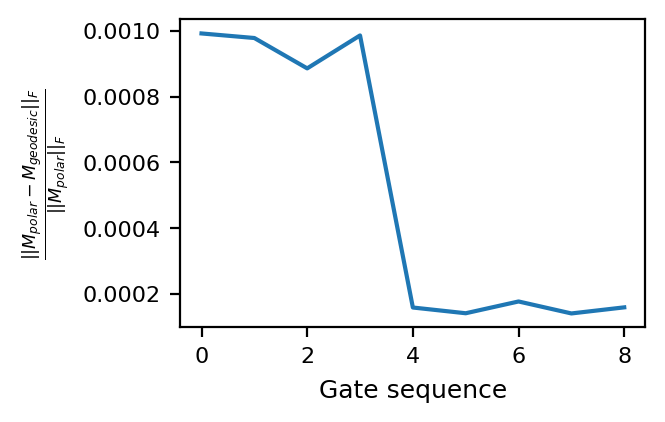

In [307]:
# they are not the same! But for how much?
norms_diff = jnp.array([jnp.linalg.norm(matrix1 - matrix2)/jnp.linalg.norm(matrix1) for matrix1, matrix2 in zip(new_isometries_polar, new_isometries_geodesic)])
plt.figure(figsize=(3,2),dpi=200)
plt.ylabel(r"$\frac{||M_{polar} - M_{geodesic}||_F}{||M_{polar}||_F}$")
plt.xlabel("Gate sequence")
plt.plot(range(len(norms_diff)), norms_diff)

# Optimization

In [308]:
from mGST.utility_functions_comparisons import run_simple_gds_on_gates_jax

In [309]:
kraus_opt_no_ls, cost_fn_history_no_ls= run_simple_gds_on_gates_jax(kraus0=kraus_tensor, povm_psd=povm_psd, state_psd=state_psd, indices_list=indices_list, prob_matrix=y, max_iter=250, target_rel_prec=1e-3, step_size=50, optimize_step=False)

iteration:  0
Initial count: 0
cost:  0.000519472111869501
iteration:  1
Initial count: 0
cost:  0.0004993224068821292
iteration:  2
Initial count: 0
cost:  0.00048627675075603
iteration:  3
Initial count: 0
cost:  0.00047646980870298574
iteration:  4
Initial count: 0
cost:  0.00046862238438107696
iteration:  5
Initial count: 0
cost:  0.0004621310704008551
iteration:  6
Initial count: 0
cost:  0.0004566390608735697
iteration:  7
Initial count: 0
cost:  0.00045191064862613715
iteration:  8
Initial count: 0
cost:  0.0004477808309085753
iteration:  9
Initial count: 0
cost:  0.00044412964872406766
iteration:  10
Initial count: 0
cost:  0.00044086732002874727
iteration:  11
Initial count: 0
cost:  0.00043792502381721733
iteration:  12
Initial count: 0
cost:  0.0004352489374371079
iteration:  13
Initial count: 0
cost:  0.00043279624771621255
iteration:  14
Initial count: 0
cost:  0.0004305324038340985
iteration:  15
Initial count: 0
cost:  0.0004284291754911251
iteration:  16
Initial count: 

In [320]:
# Why does it keep saying that the cost function is never being recompiled?
from mGST.low_level_jit import gradient_k_and_value_jit, cost_function_mps_single_gate_sequence_jit, gradient_k_and_value_nojit

In [312]:
value_test, gradient_test = gradient_k_and_value_jit(kraus_tensor, povm_psd, state_psd, indices_list, prob_matrix)

Initial count: 0


In [314]:
cost_function_mps_single_gate_sequence_jit._cache_size()

0

In [316]:
value_test = cost_function_jax_mps(kraus_tensor, povm_psd, state_psd, indices_list, prob_matrix, jit=True)

Initial count: 0
at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 10 the new count changed to: 3
at iteration 91 the new count changed to: 4
at iteration 242 the new count changed to: 5
at iteration 393 the new count changed to: 6
at iteration 544 the new count changed to: 7
at iteration 696 the new count changed to: 8
at iteration 848 the new count changed to: 9
at iteration 1000 the new count changed to: 10
at iteration 1166 the new count changed to: 11
at iteration 1332 the new count changed to: 12
at iteration 1499 the new count changed to: 13
at iteration 1666 the new count changed to: 14
at iteration 1833 the new count changed to: 15


In [317]:
cost_function_mps_single_gate_sequence_jit._cache_size()

15

In [318]:
value_test, gradient_test = gradient_k_and_value_jit(kraus_tensor, povm_psd, state_psd, indices_list, prob_matrix)

Initial count: 15


In [321]:
%timeit gradient_k_and_value_nojit(kraus_tensor, povm_psd, state_psd, indices_list, prob_matrix)

46.9 s ± 507 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [319]:
%timeit gradient_k_and_value_jit(kraus_tensor, povm_psd, state_psd, indices_list, prob_matrix)

Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
8.67 s ± 105 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
# trying if the gradient takes less time with the compiled versions
from mGST.low_level_jit import gradient_k_mps, gradient_k_mps_jit
from mGST.algorithm import gradient_descent_step

In [339]:
povm_tensor.shape, state.shape, kraus_tensor.shape,

((16, 16, 16), (16, 16), (9, 1, 16, 16))

In [340]:
povm_psd.shape, state_psd.shape

((16, 16, 1), (16, 1))

In [341]:
%timeit cost_function_jax_mps(kraus_tensor, povm_tensor, state, indices_list, prob_matrix, jit=False)

4.83 s ± 26 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [342]:
%timeit cost_function_jax_mps(kraus_tensor, povm_tensor, state, indices_list, prob_matrix, jit=True)

Initial count: 15
at iteration 0 the new count changed to: 16
at iteration 1 the new count changed to: 17
at iteration 10 the new count changed to: 18
at iteration 91 the new count changed to: 19
at iteration 242 the new count changed to: 20
at iteration 393 the new count changed to: 21
at iteration 544 the new count changed to: 22
at iteration 696 the new count changed to: 23
at iteration 848 the new count changed to: 24
at iteration 1000 the new count changed to: 25
at iteration 1166 the new count changed to: 26
at iteration 1332 the new count changed to: 27
at iteration 1499 the new count changed to: 28
at iteration 1666 the new count changed to: 29
at iteration 1833 the new count changed to: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
206 ms ± 844 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [343]:
%timeit cost_function_jax_mps(kraus_tensor, povm_tensor, state, indices_list, prob_matrix, jit=True)

Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
210 ms ± 698 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [324]:
%timeit gradient_k_mps(kraus_tensor, povm_psd, state_psd, indices_list, prob_matrix)

Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
46.4 s ± 508 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [326]:
%time _ = gradient_k_mps(kraus_tensor, povm_psd, state_psd, indices_list, prob_matrix)

Using JAX power
CPU times: user 49.9 s, sys: 1.56 s, total: 51.5 s
Wall time: 49.9 s


In [325]:
%timeit gradient_k_mps_jit(kraus_tensor, povm_psd, state_psd, indices_list, prob_matrix)

Using JAX power
Initial count: 15
Using JAX power
Initial count: 15
Using JAX power
Initial count: 15
Using JAX power
Initial count: 15
Using JAX power
Initial count: 15
Using JAX power
Initial count: 15
Using JAX power
Initial count: 15
Using JAX power
Initial count: 15
8.61 s ± 95.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [331]:
%time _ = gradient_descent_step(kraus_tensor, povm_psd, state_psd, indices_list, prob_matrix, optimize_step=False, use_geodesic=True)
# Previous:
# CPU times: user 13 s, sys: 804 ms, total: 13.8 s
# Wall time: 12 s

Initial count: 15
CPU times: user 10 s, sys: 663 ms, total: 10.7 s
Wall time: 9.94 s


In [332]:
%timeit gradient_descent_step(kraus_tensor, povm_psd, state_psd, indices_list, prob_matrix, optimize_step=False, use_geodesic=True)

Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
9.16 s ± 336 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [334]:
9.16 * 100 / 60 

15.266666666666667

In [322]:
# now retrying optimization with the compiled versions.
kraus_opt_no_ls, cost_fn_history_no_ls= run_simple_gds_on_gates_jax(kraus0=kraus_tensor, povm_psd=povm_psd, state_psd=state_psd, indices_list=indices_list, prob_matrix=y, max_iter=250, target_rel_prec=1e-3, step_size=50, optimize_step=False)

iteration:  0
Initial count: 15
cost:  0.000519472111869501
iteration:  1
Initial count: 15
cost:  0.0004993224068821292
iteration:  2
Initial count: 15
cost:  0.00048627675075603
iteration:  3
Initial count: 15
cost:  0.00047646980870298574
iteration:  4
Initial count: 15
cost:  0.00046862238438107696
iteration:  5
Initial count: 15
cost:  0.0004621310704008551
iteration:  6
Initial count: 15
cost:  0.0004566390608735697
iteration:  7
Initial count: 15
cost:  0.00045191064862613715
iteration:  8
Initial count: 15
cost:  0.0004477808309085753
iteration:  9
Initial count: 15
cost:  0.00044412964872406766
iteration:  10
Initial count: 15
cost:  0.00044086732002874727
iteration:  11
Initial count: 15
cost:  0.00043792502381721733
iteration:  12
Initial count: 15
cost:  0.0004352489374371079
iteration:  13
Initial count: 15
cost:  0.00043279624771621255
iteration:  14
Initial count: 15
cost:  0.0004305324038340985
iteration:  15
Initial count: 15
cost:  0.0004284291754911251
iteration:  16

NameError: name 'k' is not defined

Text(0, 0.5, 'Cost function')

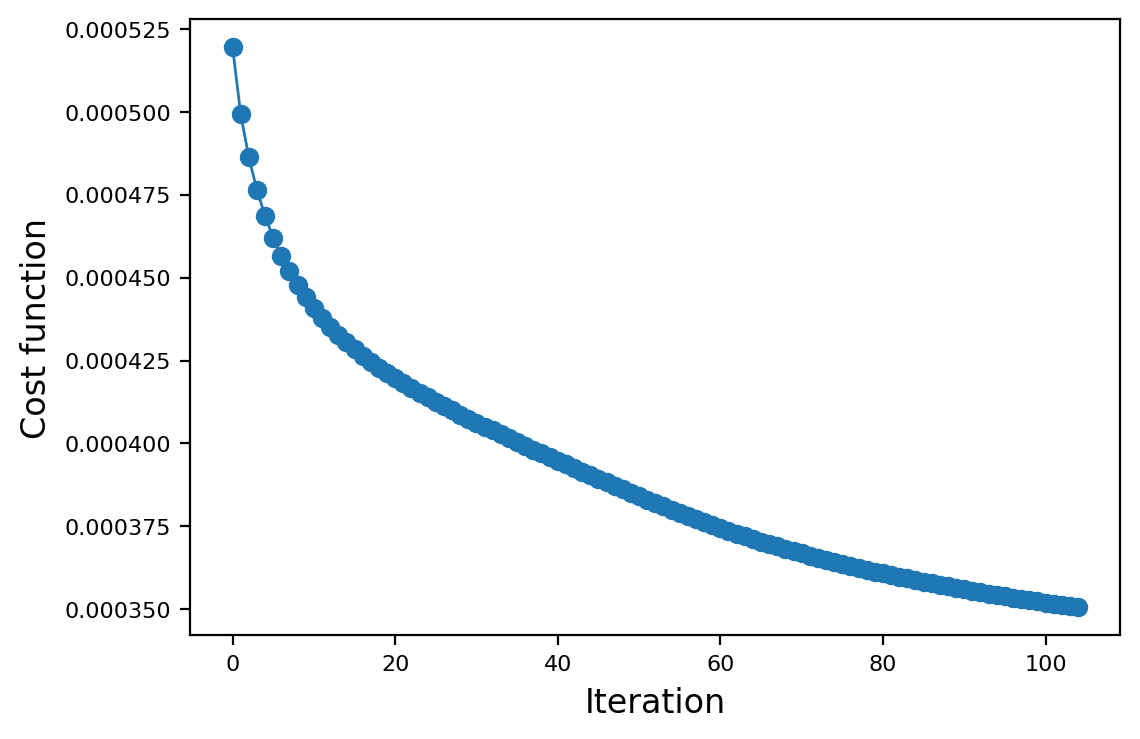

In [310]:
plt.figure(figsize=(6, 4), dpi=200)
plt.plot(cost_fn_history_no_ls, marker="o", linestyle="-", linewidth=1, markersize=6)
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Cost function", fontsize=12)

## BS tests for gradient

In [190]:
# testing the gradient from 
f_povm_jax = lambda povm_psd: cost_function_jax_mps(kraus_tensor, povm_psd, state_psd, indices_list, prob_matrix)
f_povm_numba = lambda povm_full: cost_function_numba(K_np, povm_full, rho_np, J, y_np)

def cost_alpha(alpha, initial_povm, jax:bool = True):
    "cost function f(povm + alpha*gradient) as a function of alpha"
    if jax:
        povm_alpha = initial_povm +  alpha * gradient_povm_jax/2
        return f_povm_jax(povm_alpha)
    povm_alpha = initial_povm +  2 * alpha * gradient_povm_numba
    povm_full = np.array([(povm.T.conj() @ povm).reshape(-1) for povm in povm_alpha])
    return f_povm_numba(povm_full)

In [181]:
alphas = np.arange(-0.1, 0.1, 0.005)
alphas.shape
function_value_jax = [cost_alpha(alpha, povm_psd, jax=True) for alpha in alphas]

In [197]:
alphas = np.arange(-0.2, 0.2, 0.001)
function_value_numba = [cost_alpha(alpha, A, jax=False) for alpha in alphas]

In [183]:
def tensor_inner_product_euclidean(tensor:jnp.array):
    "Euclidean norm of a tensor of rank 3"
    return jnp.real(jnp.einsum("ijk,ijk", tensor, tensor.conj()))

def linear_approx(alpha, initial_povm, jax:bool = True):
    "Linear approximation of cost_alpha around k"
    if jax:
        return f_povm_jax(initial_povm) + alpha * tensor_inner_product_euclidean(gradient_povm_jax/2)
    povm_full = np.array([(povm.T.conj() @ povm).reshape(-1) for povm in initial_povm])
    return f_povm_numba(povm_full) + alpha * tensor_inner_product_euclidean(gradient_povm_numba)

In [184]:
linear_approx_jax = [linear_approx(alpha, povm_psd) for alpha in alphas]
linear_approx_numba = [linear_approx(alpha,A) for alpha in alphas]

In [199]:

# plt.figure(dpi=200, figsize=(4,3))
# # Plot function and approximations with matching colors and different line styles
# # plt.plot(alphas, function_value_jax, color='C0', label='function: jax')           # Solid blue
# # plt.plot(alphas, linear_approx_jax, '--', color='C0', alpha=0.7, label='linear approx: jax')  # Dashed blue, transparent

# plt.xlabel(r'$\alpha$')
# plt.ylabel(r'f($\alpha$)')

# plt.legend()

# plt.figure(dpi=200, figsize=(4,3))

# plt.plot(alphas, function_value_numba, color='C1', label='function: tn')       # Solid orange
# # plt.plot(alphas, linear_approx_numba, '--', color='C1', alpha=0.7, label='linear approx: tn')    # Dashed orange, transparent

# plt.xlabel(r'$\alpha$')
# plt.ylabel(r'f($\alpha$)')

# plt.legend()